# RAG - Question Answering Git

This notebook demonstrates a basic Retrieval-Augmented Generation (RAG) system applied to code from GitHub repositories. It integrates with the GitHub API to fetch code, uses ChromaDB as a vector database to store and search code embeddings, and employs a Sentence Transformer model for generating embeddings and performing similarity searches. **The goal is to showcase how to build a system that can retrieve relevant code snippets based on a natural language query.**

keywords: RAG, LLM, github


## Git Integration

The code bellow has the purpose to interact with the GitHub API to retrieve code from specified repositories. In the context of RAG, this class serves as the data acquisition layer, fetching the raw code that will later be processed, embedded, and stored in the vector database for retrieval. By encapsulating the GitHub API logic, the `GitHubRepoFetcher` makes the process of gathering the source material for the RAG system clean and modular.

In [1]:
import requests
import os

from google.colab import userdata

class GitHubRepoFetcher:
    def __init__(self, username, github_token):
        self.username = username
        self.github_token = github_token
        self.headers = {'Authorization': f'token {self.github_token}'}

    def get_user_data(self):
        user_url = f'https://api.github.com/users/{self.username}'
        response = requests.get(user_url, headers=self.headers)
        response.raise_for_status()  # Raise an exception for bad status codes
        return response.json()

    def get_user_repos(self):
        user_data = self.get_user_data()
        repos_url = user_data['repos_url']
        repos_response = requests.get(repos_url, headers=self.headers)
        repos_response.raise_for_status()
        return repos_response.json()

    def get_repo_contents(self, repo_name):
        contents_url = f"https://api.github.com/repos/{self.username}/{repo_name}/contents"
        contents_response = requests.get(contents_url, headers=self.headers)
        contents_response.raise_for_status()
        return contents_response.json()

    def get_file_content(self, file_url):
        file_response = requests.get(file_url, headers=self.headers)
        file_response.raise_for_status()
        return file_response.text

    def fetch_all_repo_codes(self):
        repo_codes = []
        try:
            repos_data = self.get_user_repos()
            print(f"User: {self.username}")
            print(f"Name: {repos_data[0]['owner']['login']}") # Assuming first repo has owner info
            print(f"Public Repos: {len(repos_data)}")
            print("\nRepositories:")

            for repo in repos_data:
                print(f"\n- {repo['name']}")
                try:
                    contents_data = self.get_repo_contents(repo['name'])
                    for item in contents_data:
                        if item['type'] == 'file':
                            try:
                                file_url = item['download_url']
                                file_content = self.get_file_content(file_url)
                                repo_codes.append({"name": item['name'],
                                                   "content": file_content,
                                                   "repository": repo['name']})
                            except requests.exceptions.RequestException as e:
                                print(f"      Error getting file content for {item['name']}: {e}")
                                pass # Skip to next file
                except requests.exceptions.RequestException as e:
                    print(f"  Error getting contents for {repo['name']}: {e}")
                    pass # Skip to next repo

        except requests.exceptions.RequestException as e:
            print(f"Error fetching user data or repositories: {e}")

        return repo_codes

# instantiate and use the class
github_token = userdata.get('GITHUB_TOKEN')
username = 'bivar'

fetcher = GitHubRepoFetcher(username, github_token)
repo_codes = fetcher.fetch_all_repo_codes()

User: bivar
Name: bivar
Public Repos: 19

Repositories:

- bivar

- CG_ProjectFinal-Test-

- CorneV3Basic

- CVRP_APA

- data-related-studies

- desafio-6-2020

- file-name-shortener

- hands-on-ml-scikit

- llm_studies

- next_level_week

- numerico

- parallel-grid-search

- recommendationSystem

- RecoTour

- sheets-scripts

- SIGReal

- sklearn_transforms

- text-summarization

- Twitter-thread-mining


## Vector DB



### Knowledge time! What is an embedding?


***The Big Idea:*** Turning Code into Numbers

Computers don't understand words or code the way humans do. They understand numbers. The process described in that sentence is all about translating human-written code into a numerical format that a computer can work with. This numerical version is called an ***embedding*** or a ***vector***.

The main goal is to *capture the meaning* of the code in the numbers. This way, code snippets that do similar things will have similar numerical representations.

---

**A Simple Example**
Imagine you have these three simple Python functions:

Snippet 1:

```python

# A function to add two numbers
def add(a, b):
  return a + b
```

Snippet 2:

```python
# A function that returns the sum of two values
def get_sum(x, y):
  return x + y
```

Snippet 3:

```python

# A function to join two strings
def concatenate_text(str1, str2):
  return str1 + " " + str2
```

After being processed by a model, each snippet is converted into a list of numbers (an embedding). While real embeddings may have hundreds of dimensions, let's pretend they only have two for simplicity:

>Snippet 1's embedding might become: [0.91, 0.85]

>Snippet 2's embedding might become: [0.93, 0.82]

>Snippet 3's embedding might become: [0.24, 0.31]

Notice how the numbers for Snippet 1 and Snippet 2 are very close to each other. This is because both functions perform the same task: adding two numbers. Snippet 3, which does something completely different (joining text), has numbers that are very far from the other two.

By converting code to these numerical embeddings, a program can easily find related snippets just by looking for numbers that are close together.

---



### Knowledge Time! What is a Sentence Transformer model?

A Sentence Transformer is a specific type of AI model designed to be excellent at creating these meaningful numerical embeddings from chunks of text.

Think of it as a "specialized translator". Instead of translating from English to Portuguese, it "translates" from human language (or in this case, a programming language) into the mathematical language of numbers.

The "transformer" part of the name refers to the AI architecture it uses, which is very powerful at understanding the context and relationships between words in a sentence. This means it doesn't just look at individual words; it **understands** how they work together to create meaning. This is why it knows that the functions add(a, b) and get_sum(x, y) are semantically similar, even though they use different words.

---

### The Actual Implementation

Here, we're going to focus on the **Vector Database**, which is a core component of the RAG system. Think of it as a super-powered filing cabinet for our code snippets! After fetching code from GitHub, the code snippets are processed and converted into numerical representations called embeddings using a Sentence Transformer model, like the one I just mentioned.


These embeddings are then stored in our "very noice" filing cabinet (ChromaDB in this case). The vector database allows for efficient similarity searches, enabling the RAG system to quickly find relevant code snippets based on a user's query embedding. This is crucial for retrieving the most pertinent information to augment the language model's generation, kind of like finding the perfect recipe card in seconds!


In [2]:
# lets get the needed libraries
!pip install -q chromadb sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 2.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.7/517.7 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.4/128.4 kB 9.0 MB/s eta 

In [3]:
import chromadb
from sentence_transformers import SentenceTransformer

# lets initialize ChromaDB client
client = chromadb.Client()
model = SentenceTransformer('all-MiniLM-L6-v2') # you can choose models from the hugging face website

# create a collection (or get an existing one, if you already have one)
collection_name = "github_repo_codes"
try:
    collection = client.create_collection(name=collection_name)
    print(f"Collection '{collection_name}' created.")
except:
    collection = client.get_collection(name=collection_name)
    print(f"Collection '{collection_name}' already exists.")

# prepare the data for insertion into Chroma
documents = [item['content'] for item in repo_codes]
metadatas = [{"name": item['name'], "repository": item['repository']} for item in repo_codes]
ids = [f"file_{i}" for i in range(len(repo_codes))]

# generate embeddings
embeddings = model.encode(documents).tolist()

# add the data to the collection
collection.add(
    embeddings=embeddings,
    documents=documents,
    metadatas=metadatas,
    ids=ids
)

print(f"Added {len(repo_codes)} documents to the collection.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Collection 'github_repo_codes' created.
Added 50 documents to the collection.


In [4]:
# now lets verify the number of documents in the collection to see if it makes sense
count = collection.count()
print(f"Number of documents in the collection: {count}")

Number of documents in the collection: 50


## RAG

Now we're getting to the nice part! :)



### Knowledge Time! What in this heavenly earth is a RAG?

At its core, **RAG** (Retrieve-Augmented Generation) is a technique to make Large Language Models (LLMs) smarter by giving them an "open-book" to reference before they answer a question.

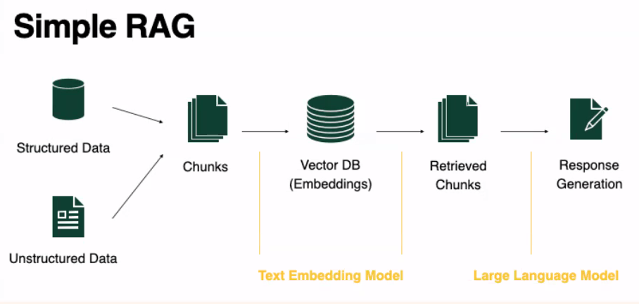

---



**How RAG Works: A 3-Step Process**
Let's say you ask a chatbot that uses RAG: "What were our company's Q3 sales goals?"

Here's what happens behind the scenes:

1. Step 1: Retrieval (The "Search")

    Instead of immediately trying to answer, the system first takes your question ("Q3 sales goals") and uses it as a search query.

    It searches a specific, private knowledge base – like your company's internal documents, PDFs, or a database (like the vector database you mentioned earlier).

    It finds the most relevant documents. For example, it might find a document named "Q3 2025 Sales Targets.pdf" and pull out the paragraph: "The target for Q3 is to achieve $5 million in new revenue with a focus on the EMEA region."

    This is the Retrieval part. It has retrieved relevant information.

2. Step 2: Augmentation (The "Enhancement")

    The system now takes the relevant information it just found and bundles it together with your original question.

    It creates a new, much more detailed prompt for the LLM. It's essentially saying:

    "Hey LLM, using the following information: [The target for Q3 is to achieve $5 million in new revenue...], please answer this user's question: 'What were our company's Q3 sales goals?'"

    This is the Augmented part. The original prompt has been enhanced with factual context.

3. Step 3: Generation (The "Answer")
    
    The LLM receives this enhanced prompt.

    With the exact facts right in front of it, it can now easily generate a precise and accurate answer.

    Final Answer: "Our company's Q3 sales goal was to achieve $5 million in new revenue, with a focus on the EMEA region."

    This is the Generation part.

### The Actual Implementation

#### Loading the hugging face model


In [5]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
query_model = SentenceTransformer('all-MiniLM-L6-v2')

#### Generating the query embedding

Using the loaded Hugging Face model to generate an embedding for the user's query.


In [6]:
# Define the user query
query = "Explain to me all the code related to Twitter API"

# Generate the embedding for the query
query_embedding = query_model.encode(query).tolist()

#### Performing similarity search

Now we are going to perform a similarity search on the Chroma vector database to find relevant code snippets.


In [7]:
N_RESULTS = 3

# Perform similarity search
results = collection.query(
    query_embeddings=query_embedding,
    n_results=N_RESULTS,
    include=['documents', 'metadatas']
)


#### Retrieving relevant documents

Extract the relevant code snippets and their associated metadata (repository and file name) from the search results.


In [8]:
retrieved_documents = []

for i in range(len(results['documents'][0])):
    document = results['documents'][0][i]
    metadata = results['metadatas'][0][i]
    name = metadata['name']
    repository = metadata['repository']
    retrieved_documents.append({"document": document, "name": name, "repository": repository})

print(retrieved_documents)

[{'document': '# Twitter-thread-mining\nMining really long Twitter messages-threads\n\nThis codebase is useful to explore twitter threads for which no direct api is avalibale in any python twitter wrapper\n\nCommand to run is \n```\n$python3 findAllTweetsInThread.py\n```\n\nTo know all tweets of a user; use\n```\n$python twitterAllTweetsOfUser.py\n```\nFor more information please explore my medium blog\n```\nhttps://medium.com/@lih.verma/mining-really-long-twitter-messages-threads-569d42bc0e1c\n```\n', 'name': 'README.md', 'repository': 'Twitter-thread-mining'}, {'document': '\nimport tweepy\nimport json\n# Enter your keys/secrets as strings in the following fields\ncredentials = {}\ncredentials[\'CONSUMER_KEY\'] = \'\'\ncredentials[\'CONSUMER_SECRET\'] = \'\'\ncredentials[\'ACCESS_TOKEN\'] = \'\'\ncredentials[\'ACCESS_SECRET\'] = \'\'\n\nauth = tweepy.OAuthHandler(credentials.get(\'CONSUMER_KEY\'), credentials.get(\'CONSUMER_SECRET\'))\nauth.set_access_token(credentials.get(\'ACCESS_T

#### Synthesizing the answer

Use the retrieved code snippets and metadata to formulate an answer to the user's query, indicating which repositories contain the requested content.


In [9]:
# Initialize an empty string to store the synthesized answer
synthesized_answer = f"Based on your query ({query}), I found the following relevant code snippets in these repositories:\n\n"

# Iterate through the retrieved documents
for doc_info in retrieved_documents:
    repository = doc_info['repository']
    name = doc_info['name']
    document = doc_info['document']

    # Taking the first 100 characters of the document for brevity
    snippet_preview = document[:100] + "..." if len(document) > 100 else document
    synthesized_answer += f"- Repository: {repository}, File: {name}\n\nSnippet: \n{snippet_preview}\n\n"
    synthesized_answer += "\n------------------------------------------------------------------------\n"

# Print the final synthesized answer
print(synthesized_answer)

Based on your query (Explain to me all the code related to Twitter API), I found the following relevant code snippets in these repositories:

- Repository: Twitter-thread-mining, File: README.md

Snippet: 
# Twitter-thread-mining
Mining really long Twitter messages-threads

This codebase is useful to expl...


------------------------------------------------------------------------
- Repository: Twitter-thread-mining, File: findAllTweetsInThread.py

Snippet: 

import tweepy
import json
# Enter your keys/secrets as strings in the following fields
credentials ...


------------------------------------------------------------------------
- Repository: Twitter-thread-mining, File: twitterAllTweetsOfUser.py

Snippet: 

import tweepy
import json
import csv
# Enter your keys/secrets as strings in the following fields
c...


------------------------------------------------------------------------



In [10]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen3-0.6B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

prompt = f"Explain me what the code in theses repositories do: {retrieved_documents}"
messages = [
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True # Switches between thinking and non-thinking modes. Default is True.
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=32768
)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

try:
    # rindex finding 151668 (</think>)
    index = len(output_ids) - output_ids[::-1].index(151668)
except ValueError:
    index = 0

thinking_content = tokenizer.decode(output_ids[:index], skip_special_tokens=True).strip("\n")
content = tokenizer.decode(output_ids[index:], skip_special_tokens=True).strip("\n")

print("thinking content:", thinking_content)
print("content:", content)


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

thinking content: <think>
Okay, let's see. The user wants to understand what the code in theses repositories do. There are three documents provided, each with a repository name and a document. The first one is about mining long Twitter threads, the second is a Python script for getting all tweets of a user, and the third is another script for handling Twitter threads.

Starting with the first document: the repository is named 'Twitter-thread-mining', and the document explains that the codebase is useful for exploring Twitter threads without direct API access. The command to run is using the script 'findAllTweetsInThread.py'. The example commands are given, and there's a link to a medium blog about mining long messages.

Next, looking at the second document, it's a Python script. The code starts by importing necessary modules and setting up credentials. Then there's a function to get all tweets for a screen name. The script uses tweepy, which is the Twitter API, and handles the user tim

## Next Steps